In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates  
# import plotly.graph_objects as go
# from Custom_tools.plotting_utils import plot_ohlc_with_sr

In [80]:
filename = "HINDALCO.NS"

In [81]:
df = pd.read_csv(f"./data/1_day_data/{filename}.csv")
df.index = pd.to_datetime(df.index)
# df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)
df.head()


,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
1970-01-01 00:00:00.000000000,1996-01-01 00:00:00+05:30,78.569794,86.391876,77.880356,78.220818,58.140087,15273,0.0,0.0
1970-01-01 00:00:00.000000001,1996-01-02 00:00:00+05:30,78.220818,78.433609,78.135704,78.391052,58.266613,17623,0.0,0.0
1970-01-01 00:00:00.000000002,1996-01-03 00:00:00+05:30,78.391052,78.135704,78.050591,78.050591,58.013557,5286,0.0,0.0
1970-01-01 00:00:00.000000003,1996-01-04 00:00:00+05:30,77.880356,77.880356,77.203690,77.203690,57.384079,12336,0.0,0.0
1970-01-01 00:00:00.000000004,1996-01-05 00:00:00+05:30,77.114319,77.199440,76.884514,76.995163,57.229084,12923,0.0,0.0


In [82]:
df["resistance"] = df["Close"].shift().rolling(10).max()
df["support"]    = df["Close"].shift().rolling(10).min()

df= df.dropna(how="any")


    ATR implementation for stop loss

In [83]:
# Calculate True Range (Wilder's definition)
df['prev_Close'] = df['Close'].shift(1)
df['tr'] = df[['High', 'Low', 'prev_Close']].apply(
    lambda x: max(x['High'] - x['Low'], 
                  abs(x['High'] - x['prev_Close']), 
                  abs(x['Low'] - x['prev_Close'])), axis=1
)
df['atr'] = df['tr'].shift().rolling(14).mean()

#### Indicators as filter

In [84]:
# Calculate RSI (14-period standard)
def calculate_rsi(data, period=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# Add RSI
df['rsi'] = calculate_rsi(df['Close'], period=14).shift()  # shift to avoid lookahead


#### Creating Strategy

    Adding a trend filter.

In [85]:
# Add simple trend filter
df['sma_50'] = df['Close'].shift().rolling(50).mean()
df['sma_200'] = df['Close'].shift().rolling(200).mean()
df["sma_20"] = df["Close"].shift().rolling(20).mean() 

# Uptrend: price > SMA50 > SMA200
df['uptrend'] = (
                 (df['sma_50'] > df['sma_200']) &
                 (df["Close"]>df["sma_20"])
                 ).astype(int)

df["downtrend"] = ( 
                #  (df['sma_50']< df['sma_200']) &
                 (df["Close"]<df["sma_20"])
                 ).astype(int)


    Calculating Entry Signal 

In [86]:
df['entry_signal'] = (
    (df['Low'] <= df['support']) &
    (df['rsi'] > 35) &
    (df['rsi'] < 55) &
    (df['uptrend'] == 1)
).astype(int)


    Calculating Entry Price

In [87]:
df["entry_price"] = np.where(df["entry_signal"]==1, df["support"], np.nan)

    Calculating Exit conditions

In [88]:
df["target_price"] = np.where(df["entry_signal"]==1, df["resistance"], np.nan )

df["stop_loss_price"] = np.where(df["entry_signal"]==1, df["entry_price"]-(1 * df["atr"]), np.nan)

#### Creating positions

In [89]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,resistance,...,rsi,sma_50,sma_200,sma_20,uptrend,downtrend,entry_signal,entry_price,target_price,stop_loss_price
1970-01-01 00:00:00.000000010,1996-01-15 00:00:00+05:30,77.199440,76.944092,76.603630,76.603630,56.938053,14685,0.0,0.0,78.391052,...,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN
1970-01-01 00:00:00.000000011,1996-01-16 00:00:00+05:30,76.603630,76.390846,75.412018,75.454575,56.083969,10573,0.0,0.0,78.391052,...,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN
1970-01-01 00:00:00.000000012,1996-01-17 00:00:00+05:30,75.454575,77.369667,75.829086,77.203690,57.384079,67555,0.0,0.0,78.050591,...,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN
1970-01-01 00:00:00.000000013,1996-01-18 00:00:00+05:30,77.203690,77.880356,74.050179,76.693001,57.004478,46407,0.0,0.0,77.203690,...,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN
1970-01-01 00:00:00.000000014,1996-01-19 00:00:00+05:30,76.693001,81.710541,76.433403,76.952606,57.197453,24085,0.0,0.0,77.203690,...,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN


    Initializing variables

In [90]:
#INitializing trade pnl logic
df["trade_pnl"] = 0.0
df["exit_reason"] = ''
df["in_position"] = 0
trade_pnls = []
starting_capital = df.iloc[0]['Close']
# starting_capital = 10000


entry_price = np.nan
stop_price = np.nan
target_price = np.nan
in_trade = False
TRANSACTION_COST = 0.0002

#For machine Learning
entry_index = None
df["ml_target"] =  np.nan
df["holding_period"] = np.nan

In [91]:
for i in range(len(df)):
    idx = df.index[i]

    #Mark if we are in position in this bar

    df.loc[idx, "in_position"] = 1 if  in_trade else 0


    #Exit logic first

    if in_trade:
        current_Low = df.loc[idx, "Low"]
        current_High = df.loc[idx, "High"]

        #Exit conditions
        if current_Low<= stop_price:
            exit_price = stop_price
            exit_reason = "STOP" 
        elif current_High >= target_price:
            exit_price = target_price
            exit_reason = "TARGET"
        else:
            exit_price = None
        #Calculating PNL
        if exit_price is not None:
            pnl_per_share_gross = exit_price - entry_price
            
            #Calculating transaction cost
            cost_entry_per_share = entry_price * TRANSACTION_COST
            cost_exit_per_share = exit_price * TRANSACTION_COST
            total_cost_per_share = cost_entry_per_share + cost_exit_per_share

            pnl_per_share_net = pnl_per_share_gross - total_cost_per_share

            #Calculate position size
            # position_value = starting_capital
            # shares = position_value/entry_price
            shares = 1

            #Total pnl for the position
            pnl_total_gross = pnl_per_share_gross * shares
            total_cost_total = total_cost_per_share * shares
            pnl_total_net = pnl_per_share_net * shares

            trade_pnls.append(pnl_total_net)

            # Assign to dataframe at exit bar

            df.loc[idx, 'trade_pnl'] =  pnl_total_net
            df.loc[idx, 'exit_reason'] = exit_reason
            # Use percentage return (comparable across stocks):
            df.loc[entry_index, 'ml_target'] = (pnl_per_share_net / entry_price) * 100
            df.loc[entry_index, "holding_period"] = i - df.index.get_loc(entry_index)


            #Reset state

            in_trade = False
            entry_price = np.nan
            stop_price = np.nan
            target_price = np.nan
    
    #Entry logic
    elif df.loc[idx, "entry_signal"] == 1:
        in_trade = True
        entry_price = df.loc[idx, "entry_price"]
        stop_price = df.loc[idx, "stop_loss_price"]
        target_price = df.loc[idx, "target_price"]

        entry_index = idx



In [92]:
np.sum(trade_pnls)

np.float64(113.91524362618588)

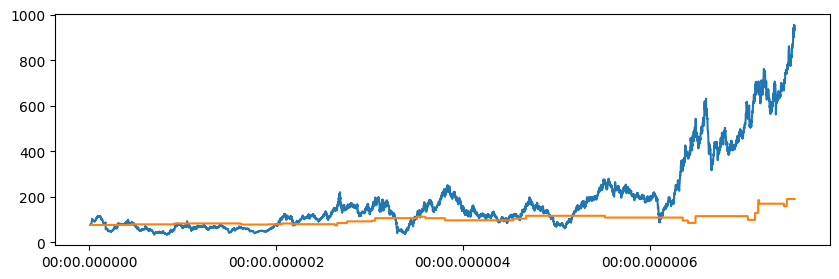

In [93]:
df["cumulative_pnl"] = df["trade_pnl"].cumsum()
df["equity_curve"] = starting_capital + df["cumulative_pnl"]

fig, ax = plt.subplots(figsize=(10,3))
ax.plot(df["Close"])
ax.plot(df["equity_curve"])

#### Trade metrics

In [94]:
import numpy as np

# Daily equity-based Sharpe (correct for intraday)
daily_equity = df.groupby(df.index.date)['equity_curve'].last()
daily_returns = daily_equity.pct_change().dropna()
sharpe = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252)

# Other key metrics
returns = df[df['trade_pnl'] != 0]['trade_pnl'] / starting_capital
total_return = (df['equity_curve'].iloc[-1] - starting_capital) / starting_capital * 100
num_trades = len(returns)
win_rate = (returns > 0).sum() / num_trades * 100 if num_trades > 0 else 0

# Max Drawdown
running_max = df['equity_curve'].cummax()
drawdown = (df['equity_curve'] - running_max) / running_max * 100
max_drawdown = drawdown.min()

# Profit Factor
gross_profit = returns[returns > 0].sum() * starting_capital
gross_loss = abs(returns[returns < 0].sum() * starting_capital)
profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf

# Print results
print(f"Total Return: {total_return:.2f}%")
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Max Drawdown: {max_drawdown:.2f}%")
print(f"Win Rate: {win_rate:.2f}%")
print(f"Total Trades: {num_trades}")
print(f"Profit Factor: {profit_factor:.2f}")

Total Return: 148.71%
Sharpe Ratio: nan
Max Drawdown: -26.73%
Win Rate: 57.14%
Total Trades: 28
Profit Factor: 2.11


In [95]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Dividends', 'Stock Splits', 'resistance', 'support', 'prev_Close',
       'tr', 'atr', 'rsi', 'sma_50', 'sma_200', 'sma_20', 'uptrend',
       'downtrend', 'entry_signal', 'entry_price', 'target_price',
       'stop_loss_price', 'trade_pnl', 'exit_reason', 'in_position',
       'ml_target', 'holding_period', 'cumulative_pnl', 'equity_curve'],
      dtype='str')

In [96]:
df

,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,resistance,...,entry_price,target_price,stop_loss_price,trade_pnl,exit_reason,in_position,ml_target,holding_period,cumulative_pnl,equity_curve
1970-01-01 00:00:00.000000010,1996-01-15 00:00:00+05:30,77.199440,76.944092,76.603630,76.603630,56.938053,14685,0.0,0.0,78.391052,...,NaN,NaN,NaN,0.0,,0,NaN,NaN,0.000000,76.603630
1970-01-01 00:00:00.000000011,1996-01-16 00:00:00+05:30,76.603630,76.390846,75.412018,75.454575,56.083969,10573,0.0,0.0,78.391052,...,NaN,NaN,NaN,0.0,,0,NaN,NaN,0.000000,76.603630
1970-01-01 00:00:00.000000012,1996-01-17 00:00:00+05:30,75.454575,77.369667,75.829086,77.203690,57.384079,67555,0.0,0.0,78.050591,...,NaN,NaN,NaN,0.0,,0,NaN,NaN,0.000000,76.603630
1970-01-01 00:00:00.000000013,1996-01-18 00:00:00+05:30,77.203690,77.880356,74.050179,76.693001,57.004478,46407,0.0,0.0,77.203690,...,NaN,NaN,NaN,0.0,,0,NaN,NaN,0.000000,76.603630
1970-01-01 00:00:00.000000014,1996-01-19 00:00:00+05:30,76.693001,81.710541,76.433403,76.952606,57.197453,24085,0.0,0.0,77.203690,...,NaN,NaN,NaN,0.0,,0,NaN,NaN,0.000000,76.603630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970-01-01 00:00:00.000007547,2026-01-19 00:00:00+05:30,938.500000,946.799988,928.450012,939.950012,939.950012,4007683,0.0,0.0,955.349976,...,NaN,NaN,NaN,0.0,,0,NaN,NaN,113.915244,190.518874
1970-01-01 00:00:00.000007548,2026-01-20 00:00:00+05:30,944.500000,949.849976,925.700012,928.099976,928.099976,5709976,0.0,0.0,955.349976,...,NaN,NaN,NaN,0.0,,0,NaN,NaN,113.915244,190.518874
1970-01-01 00:00:00.000007549,2026-01-21 00:00:00+05:30,928.750000,944.150024,926.400024,939.200012,939.200012,5590031,0.0,0.0,955.349976,...,NaN,NaN,NaN,0.0,,0,NaN,NaN,113.915244,190.518874
1970-01-01 00:00:00.000007550,2026-01-22 00:00:00+05:30,945.000000,951.400024,934.150024,944.450012,944.450012,6165965,0.0,0.0,955.349976,...,NaN,NaN,NaN,0.0,,0,NaN,NaN,113.915244,190.518874


In [97]:
df['ml_target'].values

array([nan, nan, nan, ..., nan, nan, nan], shape=(7542,))

In [98]:
df['ml_target'].notna().sum()

np.int64(28)

In [99]:
df['ml_target'].isna().sum()

np.int64(7514)

In [100]:
# Add this right after your loop
print(f"\nTotal trades executed: {len(trade_pnls)}")
print(f"ML targets stored: {df['ml_target'].notna().sum()}")
print(f"Entry signals: {(df['entry_signal'] == 1).sum()}")


Total trades executed: 28
ML targets stored: 28
Entry signals: 36


#### Adding shorting opportunities

In [101]:
df['entry_signal_short'] = (
    (df['High'] >= df['resistance']) &
    (df['rsi'] > 50) &  # Price showing strength/overbought
    (df['rsi'] < 70)   # But not extremely overbought
    & (df['downtrend'] == 1)
).astype(int)

In [102]:
# Entry at Close when price touches resistance
df["entry_price_short"] = np.where(df["entry_signal_short"]==1, 
                                    df["resistance"], 
                                    np.nan)

In [103]:

df["target_price_short"] = np.where(df["entry_signal_short"]==1, 
                                    df["support"],  # or df["Close"] - (2 * df["atr"])
                                    np.nan)

# Stop ABOVE entry (correct - you have this right!)
df["stop_loss_price_short"] = np.where(df["entry_signal_short"]==1, 
                                       df["entry_price_short"] + (1 * df["atr"]), 
                                       np.nan)

In [104]:
# Initializing trade pnl logic for SHORTS
df["trade_pnl_short"] = 0.0
df["exit_reason_short"] = ''
df["in_position_short"] = 0
trade_pnls_short = []
starting_capital_short = df.iloc[0]['Close']
# starting_capital_short = 10000

entry_price_short = np.nan
stop_price_short = np.nan
target_price_short = np.nan
in_trade_short = False
TRANSACTION_COST_SHORT = 0.0002  # Consider if shorts have Higher costs

# For machine learning
entry_index_short = None
df["ml_target_short"] = np.nan
df["holding_period_short"] = np.nan

In [105]:
for i in range(len(df)):
    idx = df.index[i]

    # Mark if we are in position in this bar
    df.loc[idx, "in_position_short"] = 1 if in_trade_short else 0

    # Exit logic first
    if in_trade_short:
        current_Low = df.loc[idx, "Low"]
        current_High = df.loc[idx, "High"]

        # Exit conditions (INVERTED for shorts)
        if current_High >= stop_price_short:  # Stop hit when price goes UP
            exit_price = stop_price_short
            exit_reason = "STOP" 
        elif current_Low <= target_price_short:  # Target hit when price goes DOWN
            exit_price = target_price_short
            exit_reason = "TARGET"
        else:
            exit_price = None
            
        # Calculating PNL
        if exit_price is not None:
            # INVERTED: profit when exit < entry for shorts
            pnl_per_share_gross = entry_price_short - exit_price  
            
            # Calculating transaction cost
            cost_entry_per_share = entry_price_short * TRANSACTION_COST_SHORT
            cost_exit_per_share = exit_price * TRANSACTION_COST_SHORT
            total_cost_per_share = cost_entry_per_share + cost_exit_per_share

            pnl_per_share_net = pnl_per_share_gross - total_cost_per_share

            # Calculate position size
            # position_value = starting_capital_short
            # shares = position_value / entry_price_short
            shares = 1

            # Total pnl for the position
            pnl_total_gross = pnl_per_share_gross * shares
            total_cost_total = total_cost_per_share * shares
            pnl_total_net = pnl_per_share_net * shares

            trade_pnls_short.append(pnl_total_net)

            # Assign to dataframe at exit bar
            df.loc[idx, 'trade_pnl_short'] = pnl_total_net
            df.loc[idx, 'exit_reason_short'] = exit_reason
            
            # Use percentage return (comparable across stocks):
            df.loc[entry_index_short, 'ml_target_short'] = (pnl_per_share_net / entry_price_short) * 100
            df.loc[entry_index_short, "holding_period_short"] = i - df.index.get_loc(entry_index_short)

            # Reset state
            in_trade_short = False
            entry_price_short = np.nan
            stop_price_short = np.nan
            target_price_short = np.nan
    
    # Entry logic
    elif (df.loc[idx, "entry_signal_short"] == 1) and (not in_trade_short):

        in_trade_short = True
        entry_price_short = df.loc[idx, "entry_price_short"]
        stop_price_short = df.loc[idx, "stop_loss_price_short"]
        target_price_short = df.loc[idx, "target_price_short"]
        
        entry_index_short = idx

In [106]:
np.sum(trade_pnls_short)

np.float64(31.43125109743405)

In [107]:
df["trade_pnl_total"] = df["trade_pnl"] + df["trade_pnl_short"]


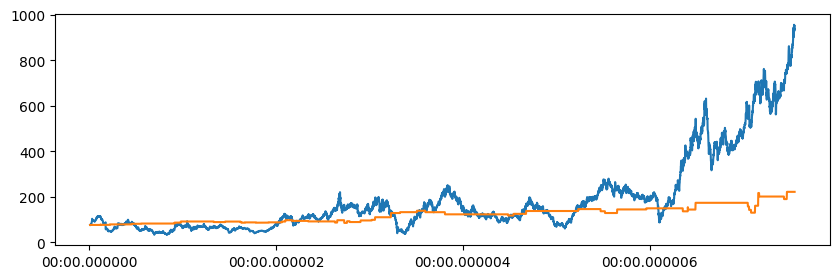

In [108]:
df["cumulative_pnl"] = df["trade_pnl_total"].cumsum()
df["equity_curve"] = starting_capital + df["cumulative_pnl"]

fig, ax = plt.subplots(figsize=(10,3))
ax.plot(df["Close"])
ax.plot(df["equity_curve"])

In [109]:
def calculate_combined_metrics(df, starting_capital, trade_pnls, trade_pnls_short):
    """
    Calculate performance metrics for combined long/short strategy
    """
    import numpy as np
    
    # Combine trade PnLs
    trade_pnls_combined = trade_pnls + trade_pnls_short
    
    # Calculate returns based on combined trades
    returns_long = df[df['trade_pnl'] != 0]['trade_pnl'] / starting_capital
    returns_short = df[df['trade_pnl_short'] != 0]['trade_pnl_short'] / starting_capital
    returns_combined = pd.concat([returns_long, returns_short]).sort_index()
    
    # Daily equity-based Sharpe (correct for intraday)
    daily_equity = df.groupby(df.index.date)['equity_curve'].last()
    daily_returns = daily_equity.pct_change().dropna()
    sharpe = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252) if len(daily_returns) > 0 else 0
    
    # Total return
    total_return = (df['equity_curve'].iloc[-1] - starting_capital) / starting_capital * 100
    
    # Trade statistics
    num_trades_long = len(trade_pnls)
    num_trades_short = len(trade_pnls_short)
    num_trades_total = num_trades_long + num_trades_short
    
    # Win rates
    win_rate_long = (returns_long > 0).sum() / num_trades_long * 100 if num_trades_long > 0 else 0
    win_rate_short = (returns_short > 0).sum() / num_trades_short * 100 if num_trades_short > 0 else 0
    win_rate_combined = len([x for x in trade_pnls_combined if x > 0]) / num_trades_total * 100 if num_trades_total > 0 else 0
    
    # Max Drawdown
    running_max = df['equity_curve'].cummax()
    drawdown = (df['equity_curve'] - running_max) / running_max * 100
    max_drawdown = drawdown.min()
    
    # Profit Factor - Combined
    gross_profit_long = sum([x for x in trade_pnls if x > 0])
    gross_loss_long = abs(sum([x for x in trade_pnls if x < 0]))
    
    gross_profit_short = sum([x for x in trade_pnls_short if x > 0])
    gross_loss_short = abs(sum([x for x in trade_pnls_short if x < 0]))
    
    gross_profit_total = gross_profit_long + gross_profit_short
    gross_loss_total = gross_loss_long + gross_loss_short
    
    profit_factor_long = gross_profit_long / gross_loss_long if gross_loss_long > 0 else np.inf
    profit_factor_short = gross_profit_short / gross_loss_short if gross_loss_short > 0 else np.inf
    profit_factor_combined = gross_profit_total / gross_loss_total if gross_loss_total > 0 else np.inf
    
    # Average trade metrics
    avg_win_long = np.mean([x for x in trade_pnls if x > 0]) if len([x for x in trade_pnls if x > 0]) > 0 else 0
    avg_loss_long = np.mean([x for x in trade_pnls if x < 0]) if len([x for x in trade_pnls if x < 0]) > 0 else 0
    
    avg_win_short = np.mean([x for x in trade_pnls_short if x > 0]) if len([x for x in trade_pnls_short if x > 0]) > 0 else 0
    avg_loss_short = np.mean([x for x in trade_pnls_short if x < 0]) if len([x for x in trade_pnls_short if x < 0]) > 0 else 0
    
    avg_win_combined = np.mean([x for x in trade_pnls_combined if x > 0]) if len([x for x in trade_pnls_combined if x > 0]) > 0 else 0
    avg_loss_combined = np.mean([x for x in trade_pnls_combined if x < 0]) if len([x for x in trade_pnls_combined if x < 0]) > 0 else 0
    
    # Expectancy
    expectancy_combined = (win_rate_combined/100 * avg_win_combined) + ((1 - win_rate_combined/100) * avg_loss_combined)
    
    # Holding period analysis
    avg_holding_long = df[df['holding_period'].notna()]['holding_period'].mean() if 'holding_period' in df.columns else 0
    avg_holding_short = df[df['holding_period_short'].notna()]['holding_period_short'].mean() if 'holding_period_short' in df.columns else 0
    
    # Print results
    print("="*60)
    print("COMBINED STRATEGY PERFORMANCE")
    print("="*60)
    print(f"\n📊 OVERALL METRICS:")
    print(f"  Total Return: {total_return:.2f}%")
    print(f"  Sharpe Ratio: {sharpe:.2f}")
    print(f"  Max Drawdown: {max_drawdown:.2f}%")
    print(f"  Profit Factor: {profit_factor_combined:.2f}")
    print(f"  Expectancy per Trade: ₹{expectancy_combined:.2f}")
    
    print(f"\n📈 LONG TRADES:")
    print(f"  Total Trades: {num_trades_long}")
    print(f"  Win Rate: {win_rate_long:.2f}%")
    print(f"  Profit Factor: {profit_factor_long:.2f}")
    print(f"  Avg Win: ₹{avg_win_long:.2f} | Avg Loss: ₹{avg_loss_long:.2f}")
    print(f"  Avg Holding Period: {avg_holding_long:.1f} bars")
    
    print(f"\n📉 SHORT TRADES:")
    print(f"  Total Trades: {num_trades_short}")
    print(f"  Win Rate: {win_rate_short:.2f}%")
    print(f"  Profit Factor: {profit_factor_short:.2f}")
    print(f"  Avg Win: ₹{avg_win_short:.2f} | Avg Loss: ₹{avg_loss_short:.2f}")
    print(f"  Avg Holding Period: {avg_holding_short:.1f} bars")
    
    print(f"\n🎯 COMBINED TRADES:")
    print(f"  Total Trades: {num_trades_total}")
    print(f"  Win Rate: {win_rate_combined:.2f}%")
    print(f"  Avg Win: ₹{avg_win_combined:.2f} | Avg Loss: ₹{avg_loss_combined:.2f}")
    
    print("="*60)
    
    # Return metrics as dictionary for further analysis
    return {
        'total_return': total_return,
        'sharpe': sharpe,
        'max_drawdown': max_drawdown,
        'profit_factor': profit_factor_combined,
        'win_rate': win_rate_combined,
        'num_trades': num_trades_total,
        'expectancy': expectancy_combined,
        'long_stats': {
            'trades': num_trades_long,
            'win_rate': win_rate_long,
            'profit_factor': profit_factor_long
        },
        'short_stats': {
            'trades': num_trades_short,
            'win_rate': win_rate_short,
            'profit_factor': profit_factor_short
        }
    }

# Usage:
metrics = calculate_combined_metrics(df, starting_capital, trade_pnls, trade_pnls_short)

COMBINED STRATEGY PERFORMANCE

📊 OVERALL METRICS:
  Total Return: 189.74%
  Sharpe Ratio: 0.00
  Max Drawdown: -24.94%
  Profit Factor: 1.87
  Expectancy per Trade: ₹2.74

📈 LONG TRADES:
  Total Trades: 28
  Win Rate: 57.14%
  Profit Factor: 2.11
  Avg Win: ₹13.55 | Avg Loss: ₹-8.57
  Avg Holding Period: 3.9 bars

📉 SHORT TRADES:
  Total Trades: 25
  Win Rate: 60.00%
  Profit Factor: 1.48
  Avg Win: ₹6.44 | Avg Loss: ₹-6.52
  Avg Holding Period: 2.6 bars

🎯 COMBINED TRADES:
  Total Trades: 53
  Win Rate: 58.49%
  Avg Win: ₹10.11 | Avg Loss: ₹-7.64


In [110]:
required_columns = ['Open', 'High', 'Low', 'Close', 'Volume', 'resistance', 'support','atr', 'rsi', 'sma_50', 'sma_200', 'sma_20','uptrend','ml_target', 'ml_target_short']
df = df[required_columns]
df.head()

,Open,High,Low,Close,Volume,resistance,support,atr,rsi,sma_50,sma_200,sma_20,uptrend,ml_target,ml_target_short
1970-01-01 00:00:00.000000010,77.199440,76.944092,76.603630,76.603630,14685,78.391052,76.603630,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
1970-01-01 00:00:00.000000011,76.603630,76.390846,75.412018,75.454575,10573,78.391052,76.603630,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
1970-01-01 00:00:00.000000012,75.454575,77.369667,75.829086,77.203690,67555,78.050591,75.454575,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
1970-01-01 00:00:00.000000013,77.203690,77.880356,74.050179,76.693001,46407,77.203690,75.454575,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
1970-01-01 00:00:00.000000014,76.693001,81.710541,76.433403,76.952606,24085,77.203690,75.454575,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN


In [111]:
# required_columns = ['Open', 'High', 'Low', 'Close', 'Volume', 'resistance', 'support','atr', 'rsi', 'sma_50', 'sma_200', 'sma_20','uptrend','downtrend']
# df = df[required_columns]
# df.head()

In [112]:
# df.to_csv(f"./machine_learning_data/{filename}.csv", index='datetime')